Simulation finished after 4 snapshots.
Saved to ./KT_DivType_general/snapshots.npz


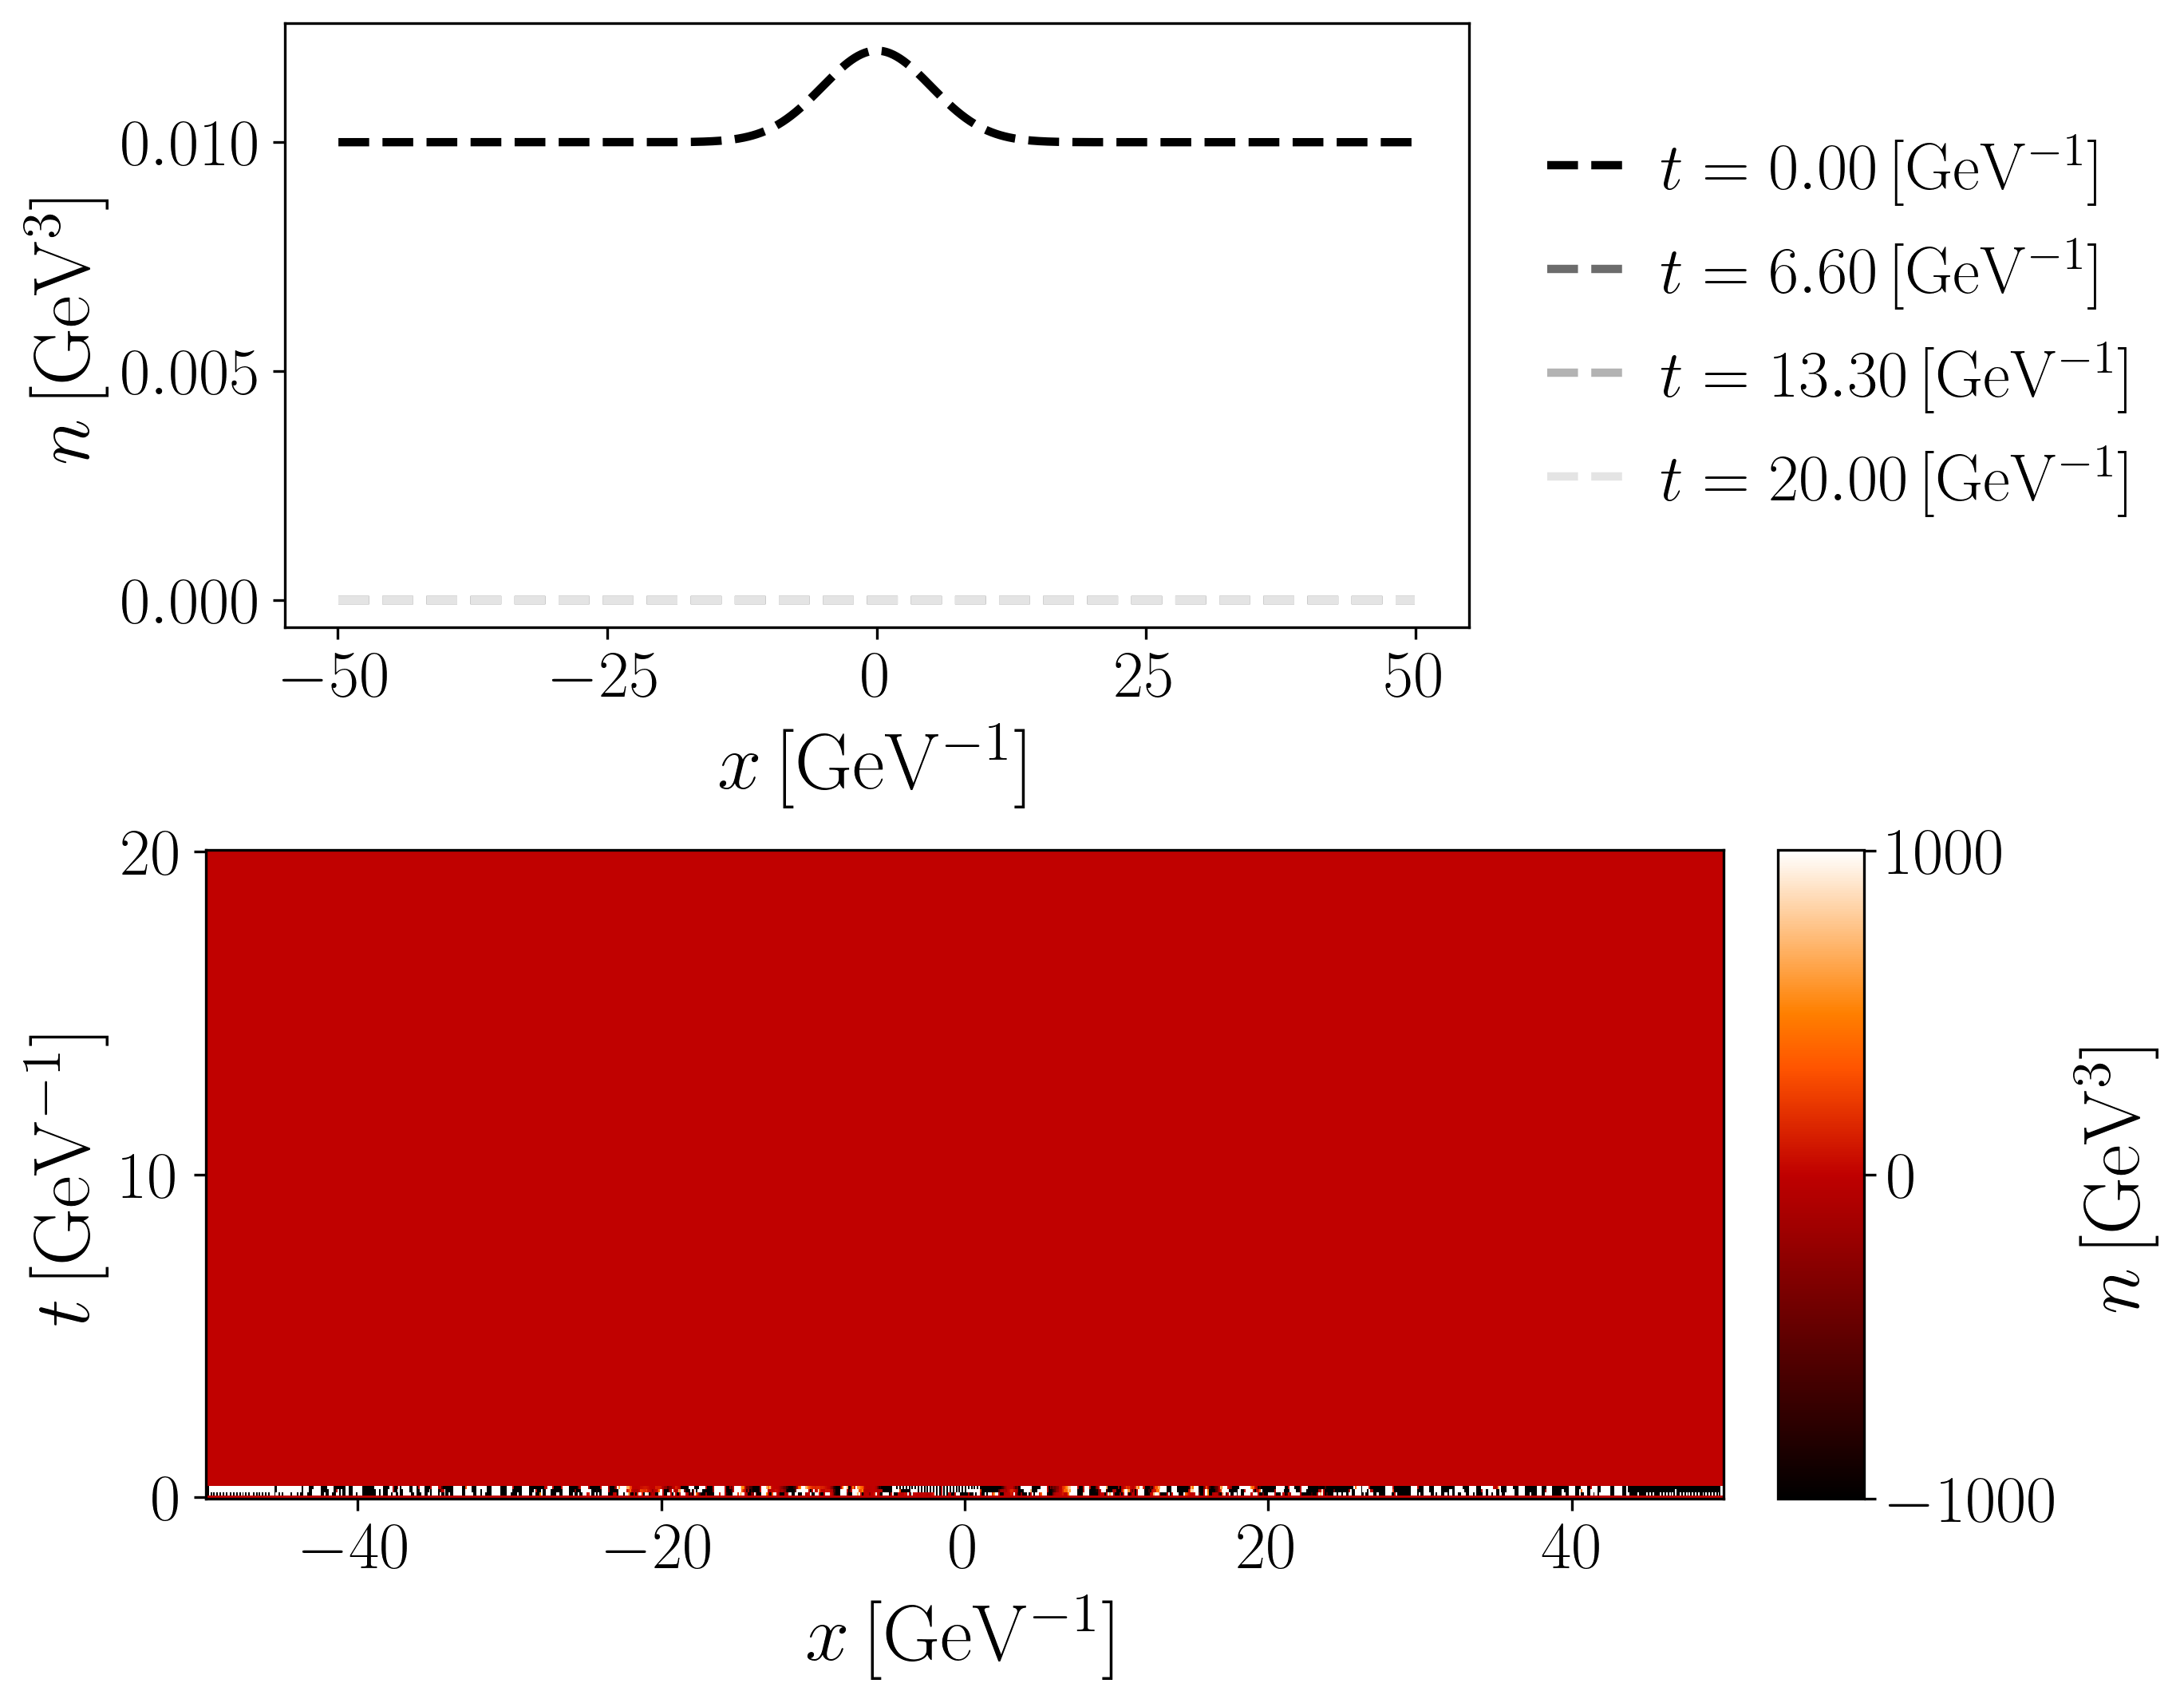

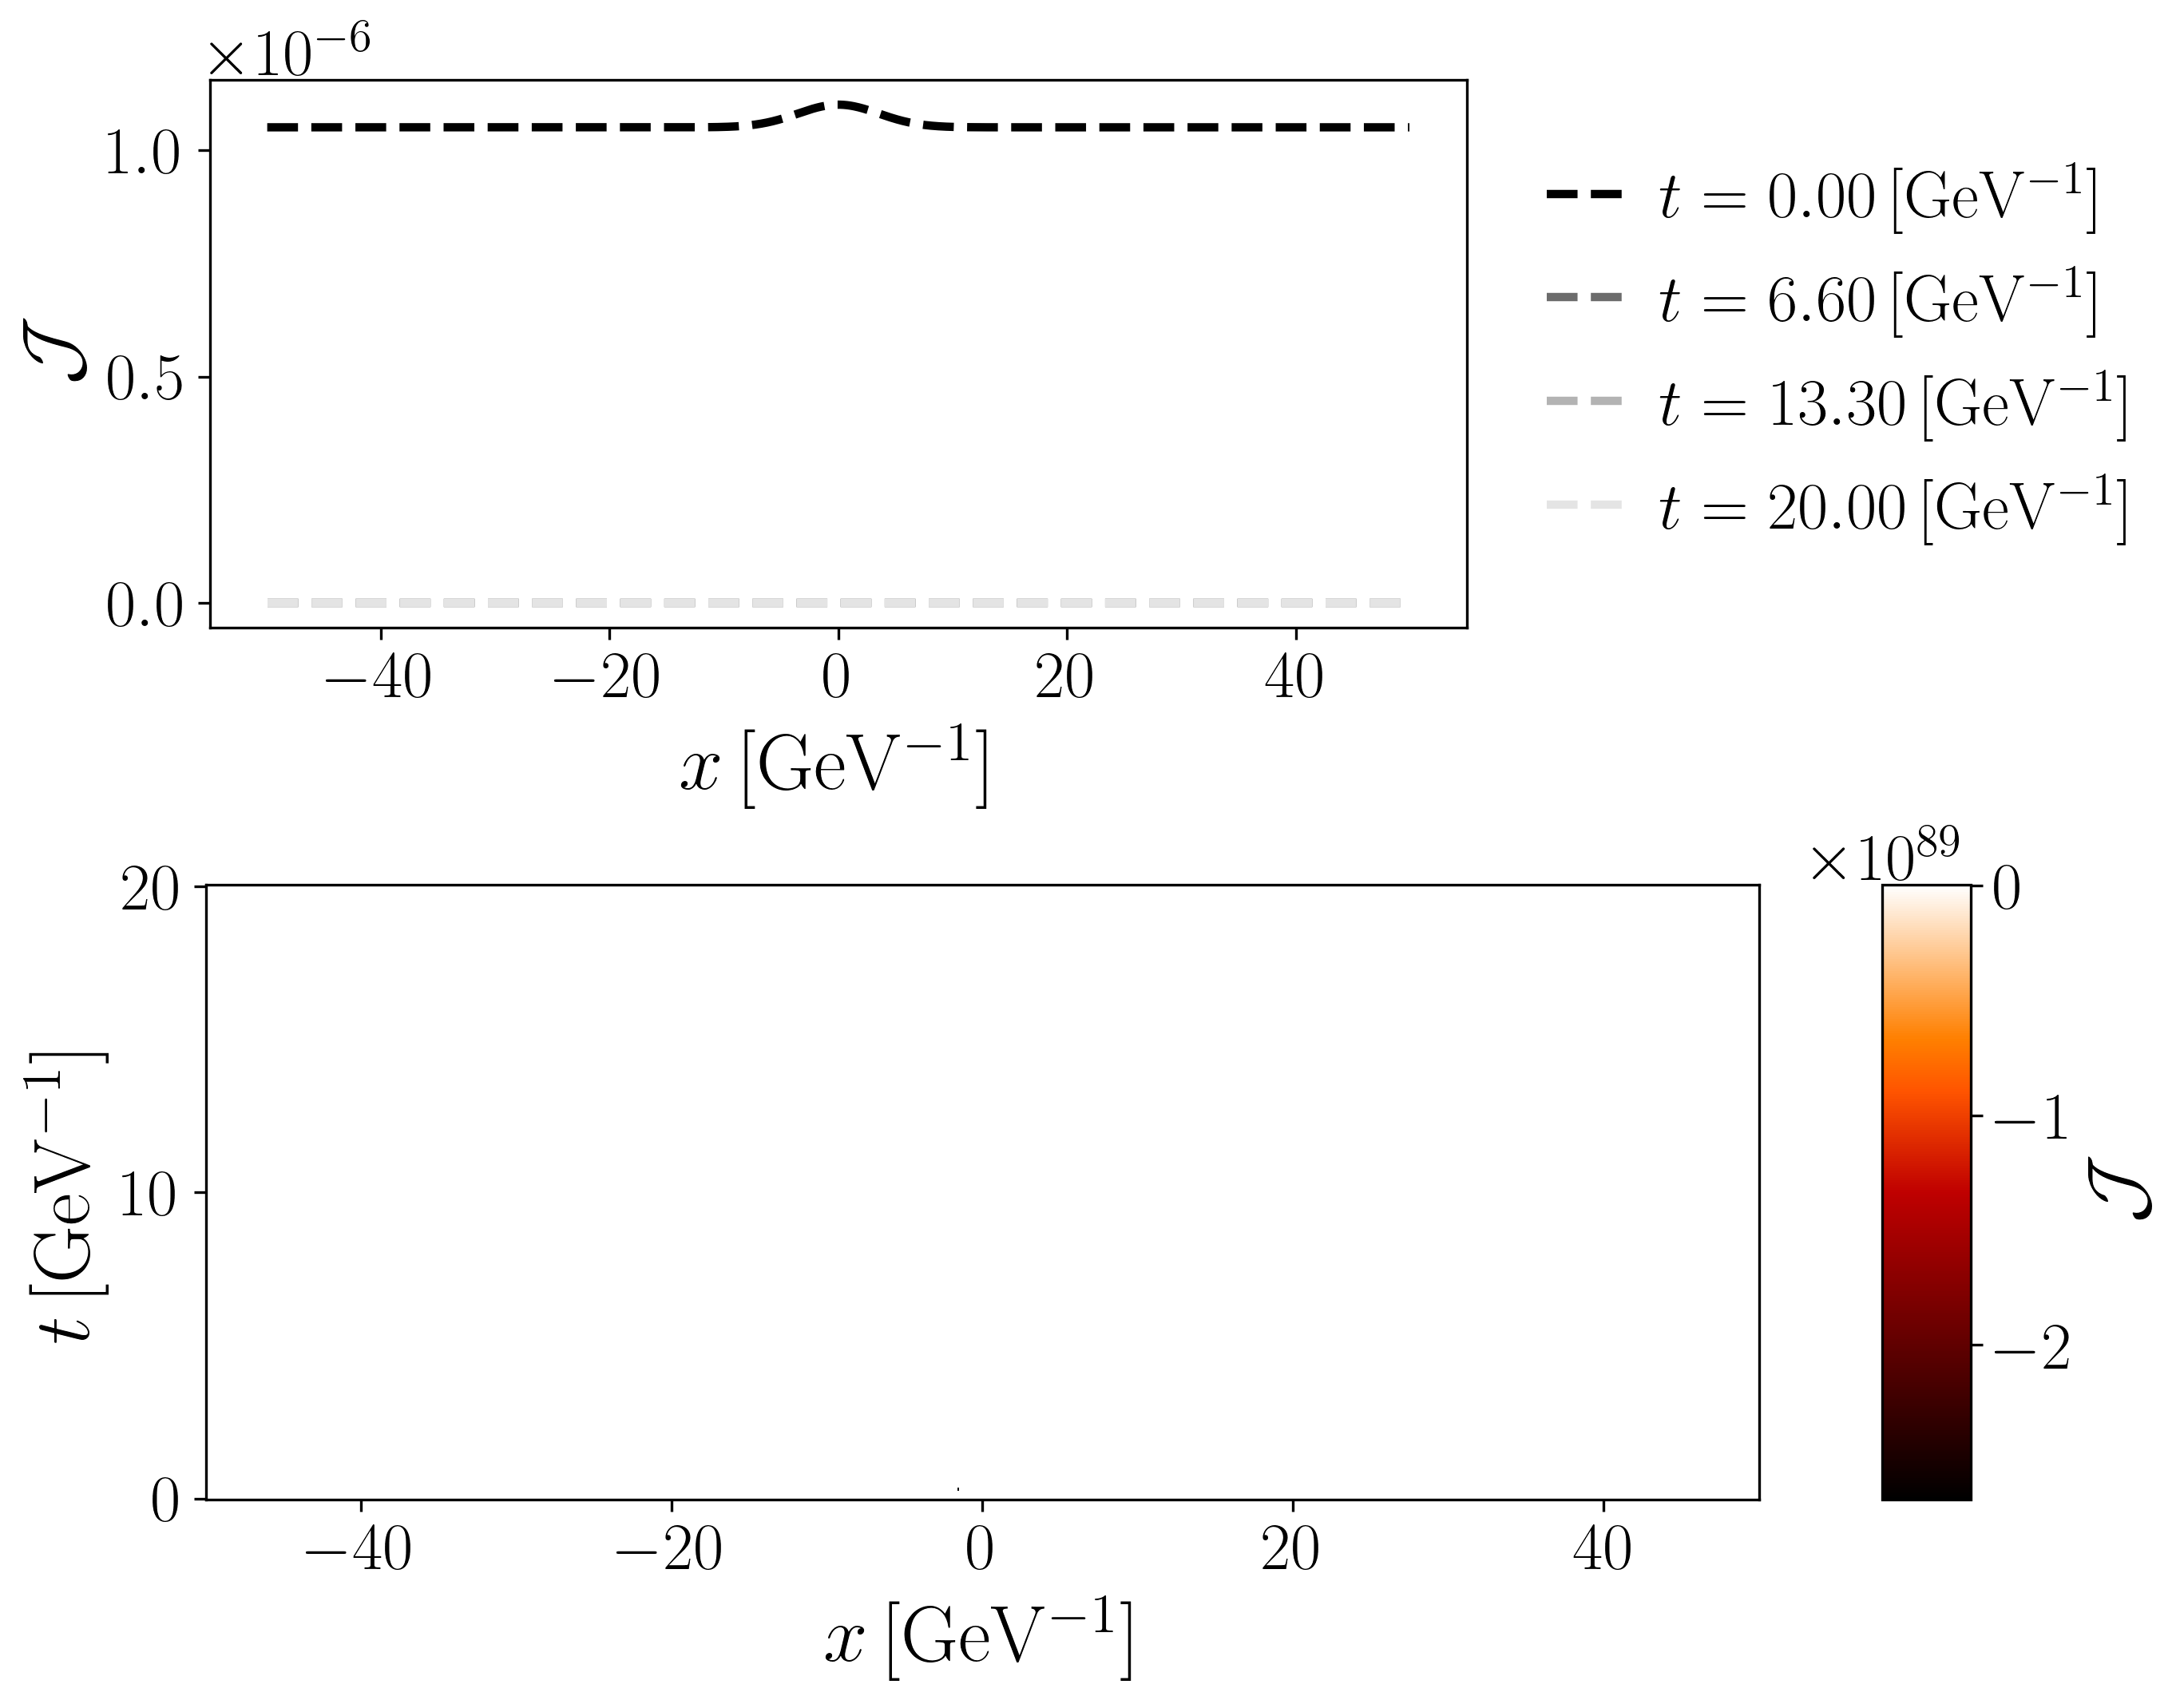

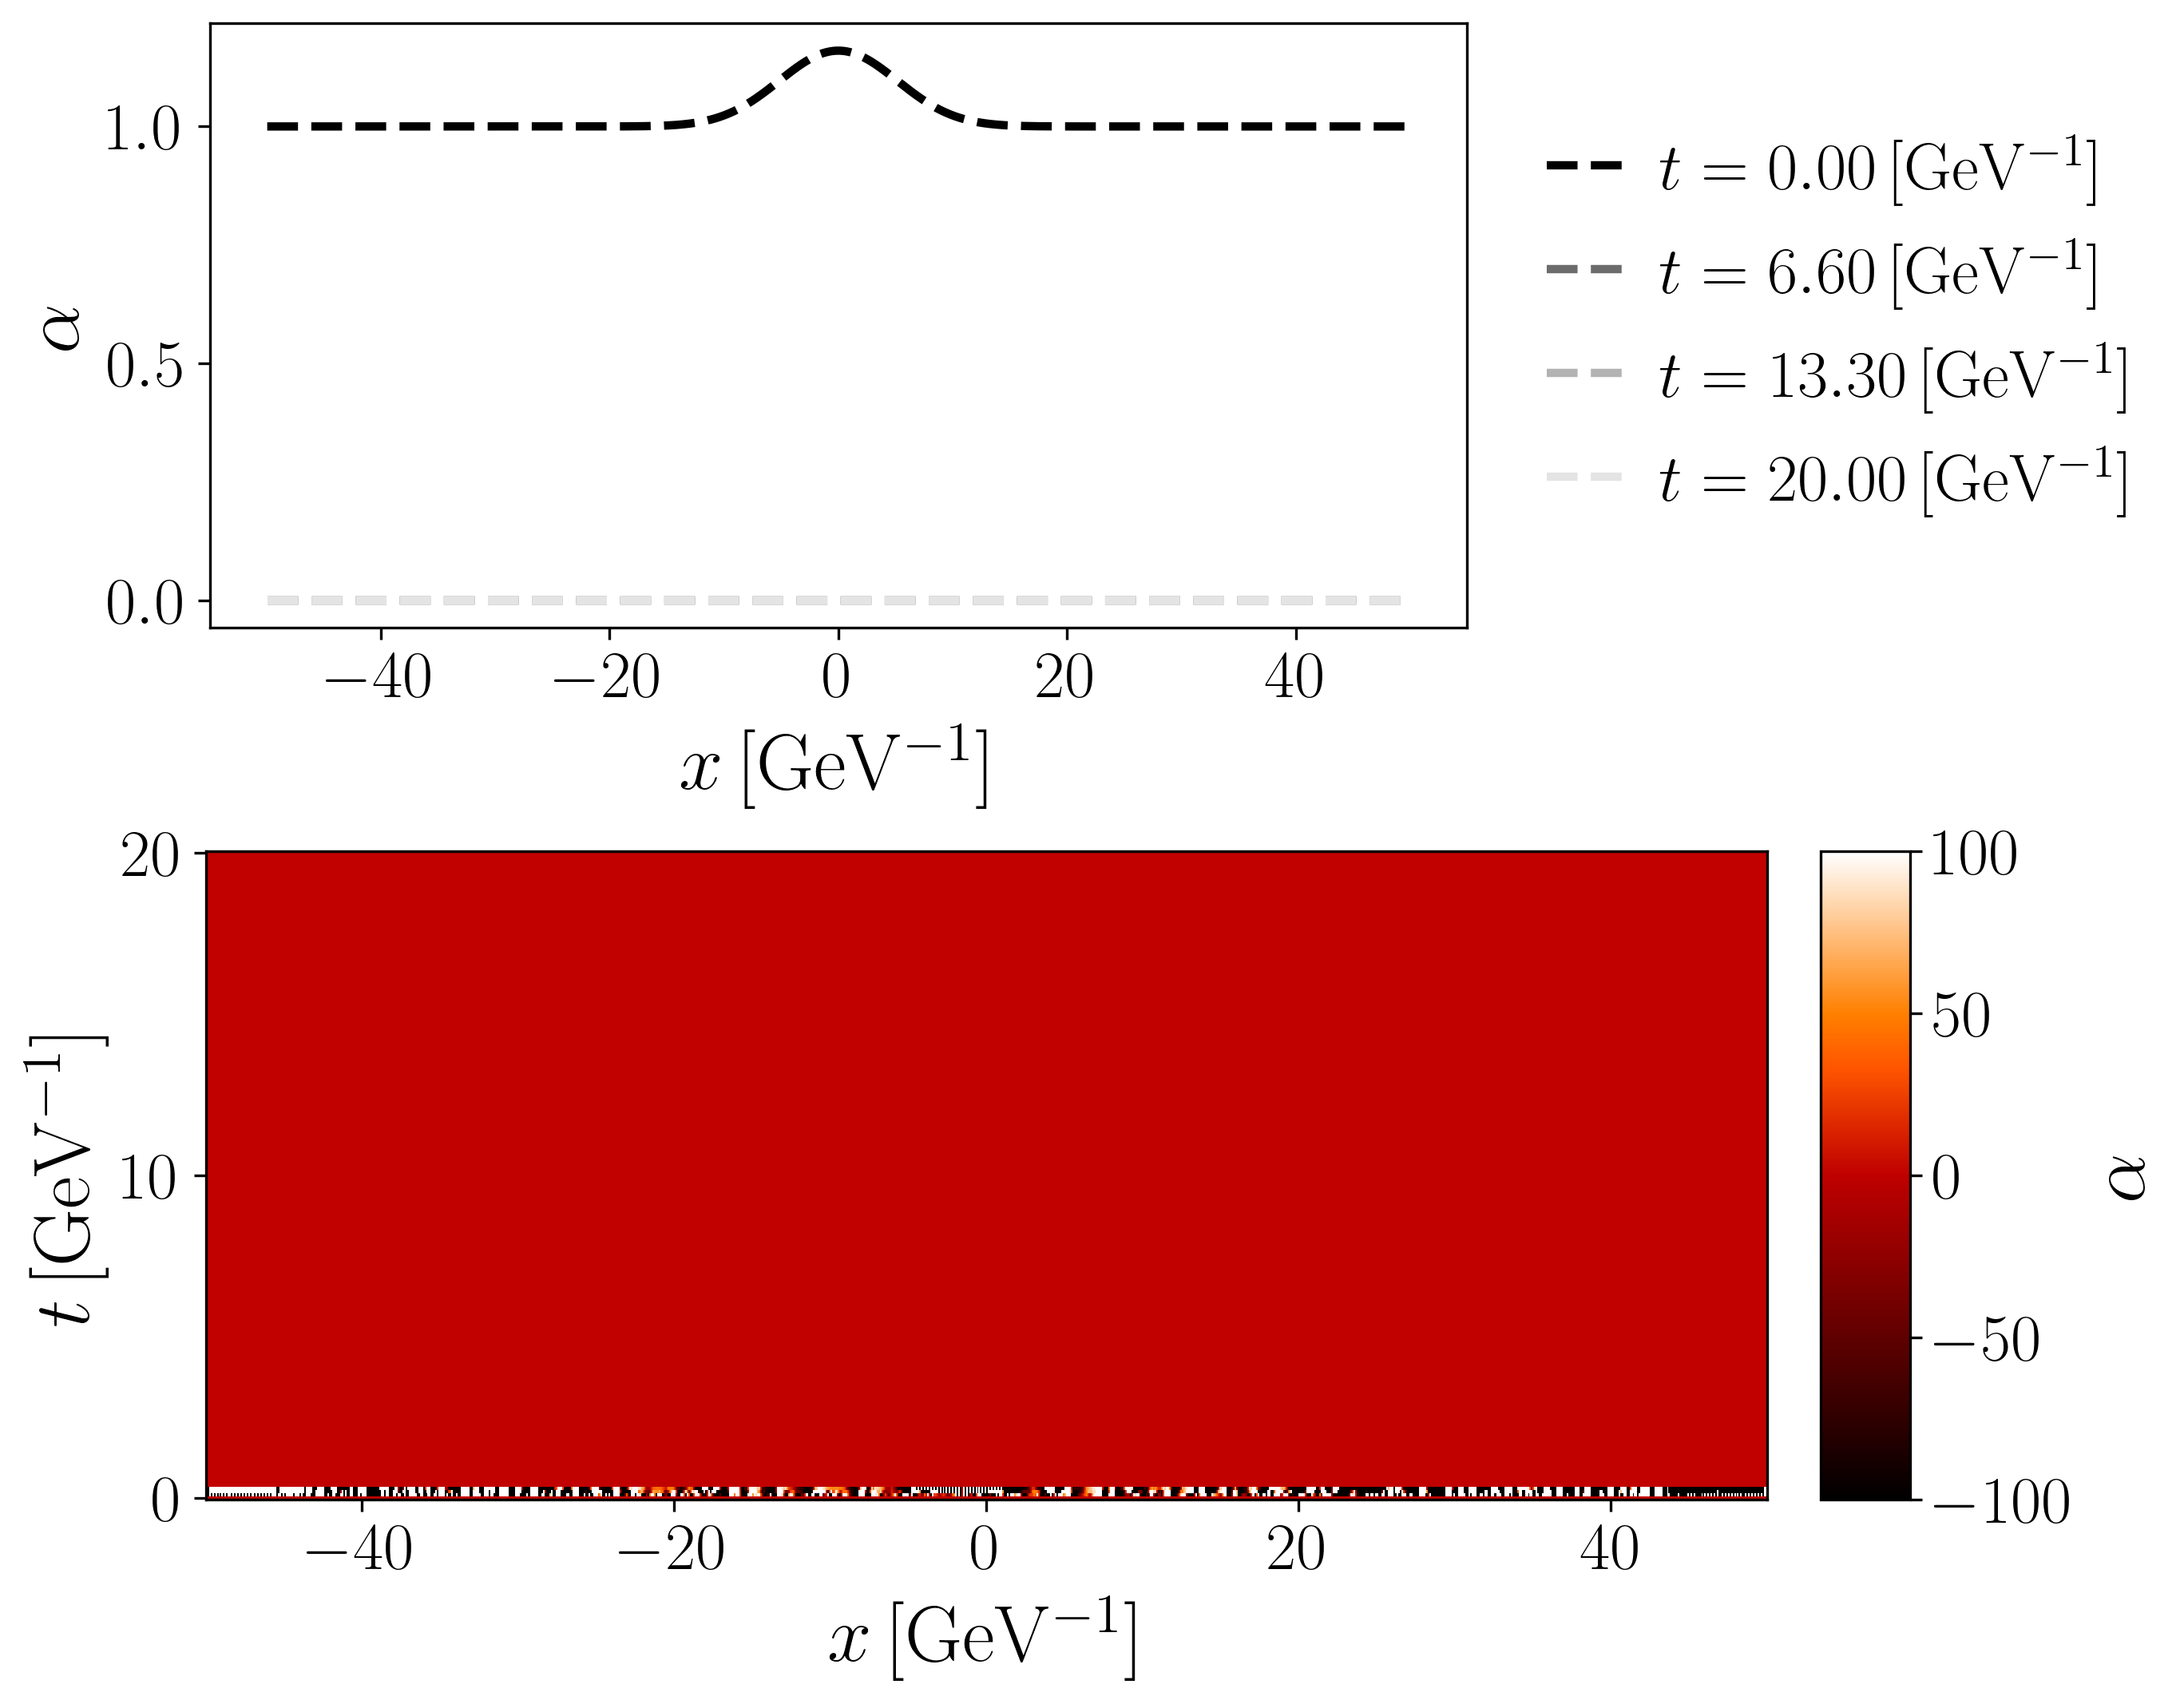

Figures saved in ./plots/KT/constant


In [34]:
# %% [Generalized KT solver with analytic wave speed – CORRECTED]
import numpy as np
from numba import jit
import matplotlib.pyplot as plt
import os
import KT_backgrounds as bg

# ---------- physical parameters ----------
L         = 50.0
t_end     = 20.0
Nx        = 1000
dx        = 2.0 * L / Nx
xc        = np.linspace(-L + 0.5*dx, L - 0.5*dx, Nx)

lam       = 0.1          # constant Λ (or use RTA switch)
USE_RTA   = False           # set True for Λ = 12/n(α,T)

# Choose one pair of functions:
T_func = bg.T_const            # or bg.T_gauss_bump, bg.T_sine, ...
v_func = bg.v_zero             # or bg.v_const_boost, bg.v_tanh_shear, ...

# ---------- constitutive functions (T-dependent) ----------
@jit(nopython=True, cache=False)
def n_func(alpha, T):
    T3 = T**3
    return (T3 / 3.0) * alpha + (T3 / 27.0) * alpha**3

@jit(nopython=True, cache=False)
def dn_dalpha_func(alpha, T):
    T3 = T**3
    return T3 / 3.0 + (T3 / 9.0) * alpha**2

@jit(nopython=True, cache=False)
def sigma_func(alpha, T):
    return (15.0 * T / (4.0 * np.pi)) * (1.0/27.0 + alpha**2 / (243.0 * np.pi**2))

@jit(nopython=True, cache=False)
def sigmaT_func(alpha, T):
    return sigma_func(alpha, T) * T

@jit(nopython=True, cache=False)
def lambda_func(alpha, T):
    if USE_RTA:
        return 12.0 / n_func(alpha, T)
    else:
        return lam * np.ones_like(alpha)

@jit(nopython=True, cache=False)
def alpha_from_n_func(n, T):
    T3 = T**3
    a = T3 / 3.0
    b = T3 / 27.0
    p = a / b
    q = -n / b
    delta = (q / 2.0)**2 + (p / 3.0)**3
    sqrt_delta = np.sqrt(delta)
    t1 = -q/2.0 + sqrt_delta
    t2 = -q/2.0 - sqrt_delta
    u = np.sign(t1) * np.power(np.abs(t1), 1.0/3.0)
    v = np.sign(t2) * np.power(np.abs(t2), 1.0/3.0)
    return u + v

@jit(nopython=True, cache=False)
def gamma_func(v):
    return 1.0 / np.sqrt(1.0 - v**2)

# ---------- helper: periodic shift ----------
@jit(nopython=True, cache=False)
def roll1d(arr, shift):
    n = arr.size
    s = shift % n
    out = np.empty_like(arr)
    if s == 0:
        out[:] = arr
    else:
        out[:s] = arr[-s:]
        out[s:] = arr[:-s]
    return out

# ---------- primitive recovery (Newton with fallback) ----------
@jit(nopython=True, cache=False)
def cons_to_prim(U1, U2, v, T, lam_local):
    gam = 1.0 / np.sqrt(1.0 - v**2)
    T3 = T**3
    # initial guess (assume v=0)
    n_guess = U1 / gam
    alpha = 3.0 * n_guess / (T3 + 1e-30)
    for _ in range(8):
        n_val = n_func(alpha, T)
        dn = dn_dalpha_func(alpha, T)           # analytic derivative
        q_val = (U2 / gam - v * alpha) / lam_local
        f1 = gam * (n_val + v * q_val) - U1
        f2 = gam * (lam_local * q_val + v * alpha) - U2
        df1_dalpha = gam * (dn - v**2 / lam_local)
        df1_dq    = gam * v
        df2_dalpha = gam * v
        df2_dq    = gam * lam_local
        det = df1_dalpha * df2_dq - df1_dq * df2_dalpha
        if abs(det) < 1e-12:
            break
        dalpha = -(f1 * df2_dq - df1_dq * f2) / det
        dq     = -(df1_dalpha * f2 - f1 * df2_dalpha) / det
        alpha += dalpha
        q_val += dq
        if abs(dalpha) < 1e-10 and abs(dq) < 1e-10:
            break
    # safety clamp: alpha should remain within reasonable range
    if alpha < -100.0: alpha = -100.0
    if alpha > 100.0: alpha = 100.0
    return alpha, q_val

# ---------- initial conditions ----------
def make_IC():
    t0 = 0.0
    p, qq, r = 0.2, 7.0, 1.0
    n_init = (p * np.exp(-(qq * xc / L)**2) + r) * 1e-2
    d, f, g = 0.05, 10.0, 1.05
    q_init = (d * np.exp(-(f * xc / L)**2) + g) * 1e-6
    T0 = T_func(t0, xc)
    alpha_init = np.array([alpha_from_n_func(ni, Ti) for ni, Ti in zip(n_init, T0)])
    v0 = v_func(t0, xc)
    gam = gamma_func(v0)
    U1_init = gam * (n_init + v0 * q_init)
    U2_init = gam * (lam * q_init + v0 * alpha_init)
    return n_init, q_init, alpha_init, U1_init, U2_init

# ---------- numerical flux (Kurganov–Tadmor) ----------
@jit(nopython=True, cache=False)
def numerical_flux(U1, U2, v_face, T_face):
    # minmod slopes
    dU1  = (roll1d(U1, -1) - U1) / dx
    dU1p = (U1 - roll1d(U1, 1)) / dx
    sU1 = np.zeros_like(U1)
    for i in range(Nx):
        if dU1[i] * dU1p[i] > 0.0:
            sU1[i] = min(abs(dU1[i]), abs(dU1p[i])) * np.sign(dU1[i])

    dU2  = (roll1d(U2, -1) - U2) / dx
    dU2p = (U2 - roll1d(U2, 1)) / dx
    sU2 = np.zeros_like(U2)
    for i in range(Nx):
        if dU2[i] * dU2p[i] > 0.0:
            sU2[i] = min(abs(dU2[i]), abs(dU2p[i])) * np.sign(dU2[i])

    U1_minus = U1 + 0.5 * dx * sU1
    U2_minus = U2 + 0.5 * dx * sU2
    U1_plus  = roll1d(U1, -1) - 0.5 * dx * roll1d(sU1, -1)
    U2_plus  = roll1d(U2, -1) - 0.5 * dx * roll1d(sU2, -1)

    H = np.zeros((2, Nx))
    for i in range(Nx):
        vf = v_face[i]
        Tf = T_face[i]
        am, qm = cons_to_prim(U1_minus[i], U2_minus[i], vf, Tf, lam)
        ap, qp = cons_to_prim(U1_plus[i], U2_plus[i], vf, Tf, lam)

        Lm = 12.0 / n_func(am, Tf) if USE_RTA else lam
        Lp = 12.0 / n_func(ap, Tf) if USE_RTA else lam

        gam = 1.0 / np.sqrt(1.0 - vf**2)
        F1m = gam * (vf * n_func(am, Tf) + qm)
        F2m = gam * (vf * Lm * qm + am)
        F1p = gam * (vf * n_func(ap, Tf) + qp)
        F2p = gam * (vf * Lp * qp + ap)

        # characteristic speeds using analytic dn/dα
        dnm = dn_dalpha_func(am, Tf)   # dn/dα
        dnp = dn_dalpha_func(ap, Tf)
        cs_m = np.sqrt(1.0 / (dnm * Lm + 1e-30))
        cs_p = np.sqrt(1.0 / (dnp * Lp + 1e-30))
        a_max = abs(vf) + max(cs_m, cs_p)

        H[0,i] = 0.5*(F1m + F1p) - 0.5*a_max*(U1_plus[i] - U1_minus[i])
        H[1,i] = 0.5*(F2m + F2p) - 0.5*a_max*(U2_plus[i] - U2_minus[i])
    return H

# ---------- RHS ----------
@jit(nopython=True, cache=False)
def rhs(U1, U2, t, xc):
    T_arr = T_func(t, xc)
    v_arr = v_func(t, xc)
    H = numerical_flux(U1, U2, v_arr, T_arr)
    dU1 = -(H[0] - roll1d(H[0], 1)) / dx
    dU2 = -(H[1] - roll1d(H[1], 1)) / dx

    alpha_c = np.zeros(Nx)
    q_c = np.zeros(Nx)
    for i in range(Nx):
        ai, qi = cons_to_prim(U1[i], U2[i], v_arr[i], T_arr[i], lam)
        alpha_c[i] = ai
        q_c[i] = qi
    dU2 -= q_c / sigmaT_func(alpha_c, T_arr)
    return dU1, dU2

# ---------- time stepping ----------
@jit(nopython=True, cache=False)
def step_RK2(U1, U2, t, xc, dt):
    dU1, dU2 = rhs(U1, U2, t, xc)
    U1_1 = U1 + dt * dU1
    U2_1 = U2 + dt * dU2
    dU1_2, dU2_2 = rhs(U1_1, U2_1, t+dt, xc)
    return (U1 + 0.5*dt*(dU1 + dU1_2),
            U2 + 0.5*dt*(dU2 + dU2_2))

# ---------- initialisation ----------
n_init, q_init, alpha_init, U1, U2 = make_IC()

save_times = np.linspace(0, t_end, 201)
n_store = np.zeros((len(save_times), Nx))
q_store = np.zeros((len(save_times), Nx))
alpha_store = np.zeros((len(save_times), Nx))
n_store[0] = n_init; q_store[0] = q_init; alpha_store[0] = alpha_init
save_idx = 0

t = 0.0
while t < t_end:
    v_arr = v_func(t, xc)
    T_arr = T_func(t, xc)
    # CFL using analytic characteristic speed
    alpha_c = np.zeros(Nx)
    for i in range(Nx):
        ai, _ = cons_to_prim(U1[i], U2[i], v_arr[i], T_arr[i], lam)
        alpha_c[i] = ai
    dn_arr = dn_dalpha_func(alpha_c, T_arr)            # analytic
    cs = np.sqrt(1.0 / (dn_arr * lam + 1e-30))
    a_max = np.max(np.abs(v_arr) + cs)
    if a_max < 1e-12:   # safeguard
        a_max = 1e-12
    dt = min(0.4 * dx / a_max, t_end - t)
    
    U1, U2 = step_RK2(U1, U2, t, xc, dt)
    t += dt
    
    while save_idx+1 < len(save_times) and t >= save_times[save_idx+1]:
        save_idx += 1
        v_s = v_func(t, xc); T_s = T_func(t, xc)
        for i in range(Nx):
            ai, qi = cons_to_prim(U1[i], U2[i], v_s[i], T_s[i], lam)
            alpha_store[save_idx,i] = ai
            q_store[save_idx,i] = qi
            n_store[save_idx,i] = n_func(ai, T_s[i])

print(f"Simulation finished after {save_idx+1} snapshots.")

# ---------- save ----------
run_dir = "./KT_DivType_general"
os.makedirs(run_dir, exist_ok=True)
np.savez(os.path.join(run_dir, "snapshots.npz"),
         t=save_times, x=xc,
         n=n_store, q=q_store, alpha=alpha_store)
print(f"Saved to {run_dir}/snapshots.npz")

# %% [KT plots in PINN style]
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm

# -------- use the same style as the PINN plotting module --------
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 18,
    'axes.titlesize': 24,
    'axes.labelsize': 24,
    'legend.fontsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'font.serif': ['Computer Modern Roman'],
    'text.latex.preamble': r'\usepackage{amsmath}',
    'figure.dpi': 300,
    'savefig.dpi': 300
})

def custom_colormap():
    cmap = plt.get_cmap("Greys_r", 256)
    vals = np.interp(
        np.linspace(0, 1, 256),
        [0.0, 1/3, 2/3, 1.0],
        [0.0, 0.35, 0.59, 0.81]
    )
    cmap = cmap(vals)
    return ListedColormap(cmap)

def plot_kt_field(field, x_eval, t_eval, ylabel, cmap_heat='gist_heat'):
    """Replica of Plotting_DivType.plot_field_panel for KT data."""
    Nt = len(t_eval)
    times = np.linspace(0, Nt-1, 4, dtype=int)
    cmap = plt.get_cmap(custom_colormap())

    fig = plt.figure(figsize=(9, 7), constrained_layout=True)
    outer = gridspec.GridSpec(2, 1, figure=fig,
                              height_ratios=[0.48, 0.52], hspace=0.18)

    gs_top = gridspec.GridSpecFromSubplotSpec(
        1, 2, subplot_spec=outer[0],
        width_ratios=[1.15, 0.32], wspace=0.05)
    ax_snap = fig.add_subplot(gs_top[0, 0])
    ax_leg  = fig.add_subplot(gs_top[0, 1])

    gs_bot = gridspec.GridSpecFromSubplotSpec(
        1, 2, subplot_spec=outer[1],
        width_ratios=[1.05, 0.06], wspace=0.05)
    ax_heat = fig.add_subplot(gs_bot[0, 0])
    cax     = fig.add_subplot(gs_bot[0, 1])

    for i, ti in enumerate(times):
        ax_snap.plot(
            x_eval, field[ti],
            color=cmap(i/(len(times)-1)),
            ls='--', lw=2.5,
            label=fr'$t={t_eval[ti]:.2f}\,[\mathrm{{GeV^{{-1}}}}]$'
        )

    ax_snap.set_xlabel(r'$x\,{\rm [GeV^{-1}]}$')
    ax_snap.set_ylabel(ylabel)

    ax_leg.axis('off')
    h, l = ax_snap.get_legend_handles_labels()
    ax_leg.legend(h, l, loc='center', frameon=False,
                  handlelength=1.2, handletextpad=0.5)

    pcm = ax_heat.pcolormesh(x_eval, t_eval, field,
                             shading='auto', cmap=cmap_heat)
    ax_heat.set_xlabel(r'$x\,{\rm [GeV^{-1}]}$')
    ax_heat.set_ylabel(r'$t\,{\rm [GeV^{-1}]}$')

    cb = fig.colorbar(pcm, cax=cax)
    cb.set_label(ylabel)
    plt.show()

# -------- generate the three panels --------
# Make sure t_eval and x_eval are the same arrays used for PINN plots.
# Here we use save_times (1D) and xc (1D) from the KT simulation.
# The field arrays have shape (Nt, Nx) with Nt = len(save_times).
plot_kt_field(n_store, xc, save_times, ylabel=r'$n\,{\rm [GeV^3]}$')
plot_kt_field(q_store, xc, save_times, ylabel=r'$\mathcal{J}$')
plot_kt_field(alpha_store, xc, save_times, ylabel=r'$\alpha$')

# ---------- Save the figures to a dedicated folder ----------
save_folder = "./plots/KT/constant"
os.makedirs(save_folder, exist_ok=True)

# We need to re-create the plots with savefig, because plot_kt_field only shows.
# Alternatively, we can modify the plot_kt_field function to accept a save path.
# Here is a quick wrapper that does exactly that:

def save_kt_field(field, x, t, ylabel, filename, cmap_heat='gist_heat'):
    """Same as plot_kt_field but saves to file instead of showing."""
    Nt = len(t)
    times = np.linspace(0, Nt-1, 4, dtype=int)
    cmap = plt.get_cmap(custom_colormap())

    fig = plt.figure(figsize=(9, 7), constrained_layout=True)
    outer = gridspec.GridSpec(2, 1, figure=fig,
                              height_ratios=[0.48, 0.52], hspace=0.18)

    gs_top = gridspec.GridSpecFromSubplotSpec(
        1, 2, subplot_spec=outer[0],
        width_ratios=[1.15, 0.32], wspace=0.05)
    ax_snap = fig.add_subplot(gs_top[0, 0])
    ax_leg  = fig.add_subplot(gs_top[0, 1])

    gs_bot = gridspec.GridSpecFromSubplotSpec(
        1, 2, subplot_spec=outer[1],
        width_ratios=[1.05, 0.06], wspace=0.05)
    ax_heat = fig.add_subplot(gs_bot[0, 0])
    cax     = fig.add_subplot(gs_bot[0, 1])

    for i, ti in enumerate(times):
        ax_snap.plot(
            x, field[ti],
            color=cmap(i/(len(times)-1)),
            ls='--', lw=2.5,
            label=fr'$t={t[ti]:.2f}\,[\mathrm{{GeV^{{-1}}}}]$'
        )

    ax_snap.set_xlabel(r'$x\,{\rm [GeV^{-1}]}$')
    ax_snap.set_ylabel(ylabel)
    ax_leg.axis('off')
    h, l = ax_snap.get_legend_handles_labels()
    ax_leg.legend(h, l, loc='center', frameon=False,
                  handlelength=1.2, handletextpad=0.5)

    pcm = ax_heat.pcolormesh(x, t, field, shading='auto', cmap=cmap_heat)
    ax_heat.set_xlabel(r'$x\,{\rm [GeV^{-1}]}$')
    ax_heat.set_ylabel(r'$t\,{\rm [GeV^{-1}]}$')
    cb = fig.colorbar(pcm, cax=cax)
    cb.set_label(ylabel)

    fig.savefig(os.path.join(save_folder, filename), dpi=300, bbox_inches='tight')
    plt.close(fig)  # close the figure to free memory

# Now save the three fields
save_kt_field(n_store, xc, save_times, ylabel=r'$n\,{\rm [GeV^3]}$', filename="field_n.pdf")
save_kt_field(q_store, xc, save_times, ylabel=r'$\mathcal{J}$', filename="field_q.pdf")
save_kt_field(alpha_store, xc, save_times, ylabel=r'$\alpha$', filename="field_alpha.pdf")

print(f"Figures saved in {save_folder}")